# Session 5 – Hierarchical Clustering

## 1. Food Delivery Orders – Manual Distance Matrix
Each order has two features: **delivery_time** (minutes) and **distance** (km).

| Order | delivery_time (x) | distance (y) |
|---|---|---|
| O1 | 10 | 2 |
| O2 | 12 | 3 |
| O3 | 25 | 8 |
| O4 | 28 | 9 |
| O5 | 15 | 4 |
| O6 | 40 | 14 |

Formula: $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

### Step-by-step calculation (15 unique pairs)
| Pair | Calculation | Distance |
|---|---|---|
| O1 – O2 | √((12−10)² + (3−2)²) = √(4 + 1) = √5 | **2.24** |
| O1 – O3 | √((25−10)² + (8−2)²) = √(225 + 36) = √261 | **16.16** |
| O1 – O4 | √((28−10)² + (9−2)²) = √(324 + 49) = √373 | **19.31** |
| O1 – O5 | √((15−10)² + (4−2)²) = √(25 + 4) = √29 | **5.39** |
| O1 – O6 | √((40−10)² + (14−2)²) = √(900 + 144) = √1044 | **32.31** |
| O2 – O3 | √((25−12)² + (8−3)²) = √(169 + 25) = √194 | **13.93** |
| O2 – O4 | √((28−12)² + (9−3)²) = √(256 + 36) = √292 | **17.09** |
| O2 – O5 | √((15−12)² + (4−3)²) = √(9 + 1) = √10 | **3.16** |
| O2 – O6 | √((40−12)² + (14−3)²) = √(784 + 121) = √905 | **30.08** |
| O3 – O4 | √((28−25)² + (9−8)²) = √(9 + 1) = √10 | **3.16** |
| O3 – O5 | √((15−25)² + (4−8)²) = √(100 + 16) = √116 | **10.77** |
| O3 – O6 | √((40−25)² + (14−8)²) = √(225 + 36) = √261 | **16.16** |
| O4 – O5 | √((15−28)² + (4−9)²) = √(169 + 25) = √194 | **13.93** |
| O4 – O6 | √((40−28)² + (14−9)²) = √(144 + 25) = √169 | **13.00** |
| O5 – O6 | √((40−15)² + (14−4)²) = √(625 + 100) = √725 | **26.93** |

### Initial distance matrix (symmetric, diagonal = 0)
| | O1 | O2 | O3 | O4 | O5 | O6 |
|---|---|---|---|---|---|---|
| **O1** | 0 | 2.24 | 16.16 | 19.31 | 5.39 | 32.31 |
| **O2** | 2.24 | 0 | 13.93 | 17.09 | 3.16 | 30.08 |
| **O3** | 16.16 | 13.93 | 0 | 3.16 | 10.77 | 16.16 |
| **O4** | 19.31 | 17.09 | 3.16 | 0 | 13.93 | 13.00 |
| **O5** | 5.39 | 3.16 | 10.77 | 13.93 | 0 | 26.93 |
| **O6** | 32.31 | 30.08 | 16.16 | 13.00 | 26.93 | 0 |

**Observation:** The smallest distance is **O1 – O2 (2.24)**, so in agglomerative clustering O1 and O2 would be merged first.
O6 is far from every other order (a long, distant delivery) and would be merged last.

In [1]:
import math
import numpy as np
import pandas as pd

orders = pd.DataFrame({
    "order": ["O1", "O2", "O3", "O4", "O5", "O6"],
    "delivery_time": [10, 12, 25, 28, 15, 40],
    "distance": [2, 3, 8, 9, 4, 14],
}).set_index("order")

# Build the distance matrix "manually" with the Euclidean formula (no library distance functions)
n = len(orders)
dist_matrix = np.zeros((n, n))
pts = orders.values
for i in range(n):
    for j in range(n):
        x1, y1 = pts[i]
        x2, y2 = pts[j]
        dist_matrix[i, j] = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

dist_df = pd.DataFrame(dist_matrix, index=orders.index, columns=orders.index).round(2)
print(dist_df)

# Closest pair (ignoring the diagonal)
masked = dist_df.where(~np.eye(n, dtype=bool))
i, j = np.unravel_index(np.nanargmin(masked.values), masked.shape)
print(f"\nClosest pair: {orders.index[i]} & {orders.index[j]} -> {masked.iloc[i, j]:.2f}")

order     O1     O2     O3     O4     O5     O6
order                                          
O1      0.00   2.24  16.16  19.31   5.39  32.31
O2      2.24   0.00  13.93  17.09   3.16  30.08
O3     16.16  13.93   0.00   3.16  10.77  16.16
O4     19.31  17.09   3.16   0.00  13.93  13.00
O5      5.39   3.16  10.77  13.93   0.00  26.93
O6     32.31  30.08  16.16  13.00  26.93   0.00

Closest pair: O1 & O2 -> 2.24


## 2. Agglomerative Clustering on 8 Songs + Dendrogram
Features: **tempo** (BPM) and **energy** (0–1). Because tempo is in the 60–180 range while energy is 0–1,
features are standardised so both contribute equally to the distance.

In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

songs = pd.DataFrame({
    "song":   ["Blinding Lights", "Levitating", "Believer", "Thunder",
               "Perfect", "All of Me", "Lose Yourself", "Shape of You"],
    "tempo":  [171, 103, 125, 168, 63, 63, 171, 96],
    "energy": [0.73, 0.82, 0.78, 0.81, 0.45, 0.26, 0.87, 0.65],
}).set_index("song")

X_songs = StandardScaler().fit_transform(songs[["tempo", "energy"]])
songs

,tempo,energy
song,,
Blinding Lights,171,0.73
Levitating,103,0.82
Believer,125,0.78
Thunder,168,0.81
Perfect,63,0.45
All of Me,63,0.26
Lose Yourself,171,0.87
Shape of You,96,0.65


                 tempo  energy  cluster
song                                   
Levitating         103    0.82        0
Believer           125    0.78        0
Shape of You        96    0.65        0
Perfect             63    0.45        1
All of Me           63    0.26        1
Blinding Lights    171    0.73        2
Thunder            168    0.81        2
Lose Yourself      171    0.87        2


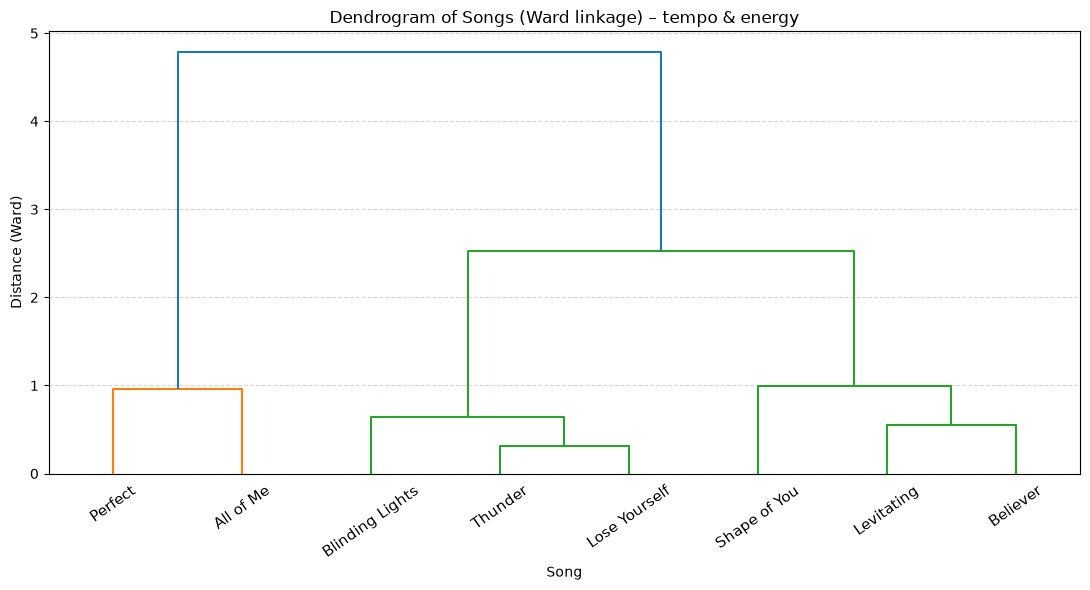

In [3]:
# sklearn agglomerative clustering (Ward linkage) into 3 groups
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
songs["cluster"] = agg.fit_predict(X_songs)
print(songs.sort_values("cluster"))

# scipy linkage + dendrogram
Z = linkage(X_songs, method="ward")

plt.figure(figsize=(11, 6))
dendrogram(Z, labels=songs.index.tolist(), leaf_rotation=35, leaf_font_size=11,
           color_threshold=0.7 * Z[:, 2].max())
plt.title("Dendrogram of Songs (Ward linkage) – tempo & energy")
plt.xlabel("Song")
plt.ylabel("Distance (Ward)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

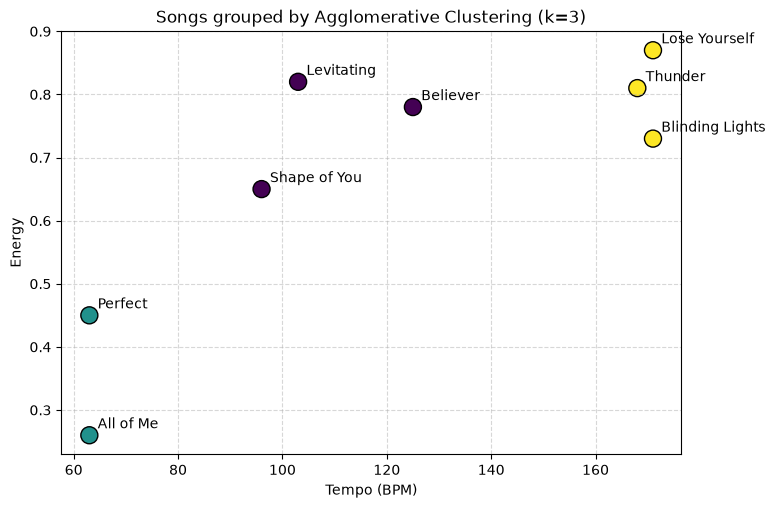

In [4]:
# Scatter plot of the songs coloured by cluster
plt.figure(figsize=(8, 5.5))
plt.scatter(songs["tempo"], songs["energy"], c=songs["cluster"], cmap="viridis", s=150, edgecolor="black")
for name, row in songs.iterrows():
    plt.annotate(name, (row["tempo"], row["energy"]), xytext=(6, 5), textcoords="offset points")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Energy")
plt.title("Songs grouped by Agglomerative Clustering (k=3)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Comparing Linkage Methods: Single vs Complete vs Average
- **Single** – distance between the *closest* pair of points of two clusters
- **Complete** – distance between the *farthest* pair of points
- **Average** – average of all pairwise distances

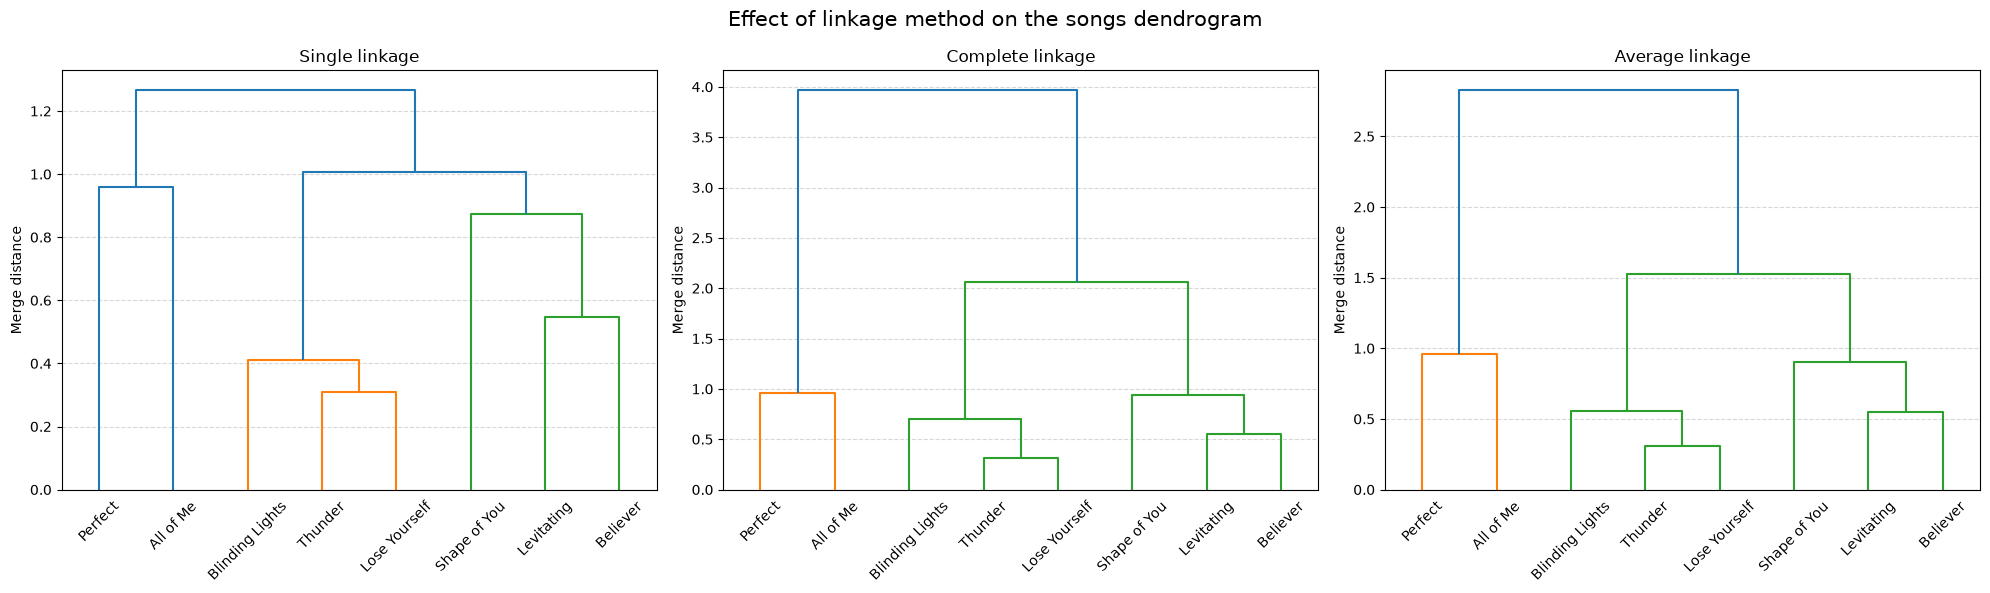

In [5]:
methods = ["single", "complete", "average"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, method in zip(axes, methods):
    Zm = linkage(X_songs, method=method)
    dendrogram(Zm, labels=songs.index.tolist(), ax=ax, leaf_rotation=45, leaf_font_size=10,
               color_threshold=0.7 * Zm[:, 2].max())
    ax.set_title(f"{method.capitalize()} linkage")
    ax.set_ylabel("Merge distance")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Effect of linkage method on the songs dendrogram", fontsize=15)
plt.tight_layout()
plt.show()

In [6]:
# Numerical comparison: merge heights and 3-cluster assignments for each linkage
summary = {}
for method in methods:
    Zm = linkage(X_songs, method=method)
    print(f"{method.upper():<9} merge heights: {np.round(Zm[:, 2], 2).tolist()}")
    summary[method] = AgglomerativeClustering(n_clusters=3, linkage=method).fit_predict(X_songs)

print()
print(pd.DataFrame(summary, index=songs.index))

SINGLE    merge heights: [0.31, 0.41, 0.55, 0.87, 0.96, 1.01, 1.27]
COMPLETE  merge heights: [0.31, 0.55, 0.71, 0.94, 0.96, 2.06, 3.97]
AVERAGE   merge heights: [0.31, 0.55, 0.56, 0.91, 0.96, 1.52, 2.83]

                 single  complete  average
song                                      
Blinding Lights       2         2        2
Levitating            1         1        1
Believer              1         1        1
Thunder               2         2        2
Perfect               0         0        0
All of Me             0         0        0
Lose Yourself         2         2        2
Shape of You          1         1        1


### Observations
- **Single linkage** produces the **lowest merge heights** and a "chained" tree – songs are added to an existing cluster one at a time,
  because only the single closest pair matters. This can create long, straggly clusters.
- **Complete linkage** produces the **highest merge heights** and more **compact, balanced** groups, since a cluster is only merged when *all* its songs are reasonably close.
- **Average linkage** sits **in between** – it is less sensitive to a single close pair (single) or a single far outlier (complete).
- In all three trees the natural groups stay recognisable: **slow, low-energy ballads** (*Perfect, All of Me*), **fast, high-energy tracks**
  (*Blinding Lights, Thunder, Lose Yourself*) and **mid-tempo pop** (*Levitating, Believer, Shape of You*) – what changes is *how high* and in *what order* they join.

## 4. Function Returning Euclidean and Manhattan Distance
- Euclidean: $\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$ – straight-line distance
- Manhattan: $|x_2-x_1| + |y_2-y_1|$ – grid / city-block distance

In [7]:
def distances(p1, p2):
    """Return (euclidean, manhattan) distance between two 2D points (x1, y1) and (x2, y2)."""
    (x1, y1), (x2, y2) = p1, p2
    euclidean = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    manhattan = abs(x2 - x1) + abs(y2 - y1)
    return euclidean, manhattan


# Test on three pairs of orders from the Q1 dataset
pairs = [("O1", "O2"), ("O3", "O4"), ("O1", "O6")]
for a, b in pairs:
    p1 = tuple(orders.loc[a]); p2 = tuple(orders.loc[b])
    e, m = distances(p1, p2)
    print(f"{a}{p1} <-> {b}{p2}:  Euclidean = {e:.2f},  Manhattan = {m}")

O1(10, 2) <-> O2(12, 3):  Euclidean = 2.24,  Manhattan = 3
O3(25, 8) <-> O4(28, 9):  Euclidean = 3.16,  Manhattan = 4
O1(10, 2) <-> O6(40, 14):  Euclidean = 32.31,  Manhattan = 42


**Note:** Manhattan distance is always ≥ Euclidean distance; they are equal only when the points differ along a single axis.

## 5. Choosing a Linkage Method for a "Similar Movies" Feature

**Choice: Average linkage** (with a cosine / correlation distance on the user-rating vectors).

**Why:**
- **Robust to noise:** Rating data is sparse and noisy (a few users rate oddly). Average linkage uses *all* pairwise similarities between two groups,
  so one unusual rating cannot merge unrelated movies – unlike **single linkage**, which would chain e.g. a horror film to a comedy via one shared fan.
- **Not too strict:** **Complete linkage** is dominated by the single most dissimilar pair, so it can split genuinely similar movies just because of one outlier movie in the group.
- **Works with any distance:** Movie similarity is best measured with **cosine similarity** (taste pattern, not rating scale – a harsh rater and a generous rater who like the same movies should match).
  **Ward** only works with Euclidean distance and favours equal-sized spherical clusters, while real movie groups vary a lot in size (huge "blockbusters" group vs small niche "art-house" group).
- **Result:** Clusters represent movies that are, *on average*, liked by the same audience – exactly what "Because you watched X" recommendations need.

*(If the ratings were dense and converted to Euclidean features, **Ward** would be a good alternative, as it creates compact, balanced clusters.)*